In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB

### DATA LOADING 

In [4]:
df = pd.read_excel("New_columns.xlsx")

### DATA UNDERSTANDING 

In [5]:
df.head()

,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales,Sales_Category
0,TXN100002,2025-07-22,Customer,Swap,BSC,20555.75,32.61,VIP,America,203,38.98,Pass,Yes,929.0,12870.12,24666.900,0
1,TXN100003,2025-12-27,NaN,Staking,Solana,25571.60,16.49,Institutional,Europe,152,56.57,Pass,No,519.0,5099.70,30685.920,1
2,TXN100004,2025-07-27,Operational,DeFi,Polygon,40219.77,39.93,Retail,Europe,27,82.62,Review,Yes,2002.0,22341.17,48263.724,1
3,TXN100005,2025-08-27,Customer,saving,Polygon,44989.59,18.03,VIP,Europe,177,1.05,Pass,No,3205.0,31676.08,-5000.000,0
4,TXN100006,2025-12-16,Treasury,DeFi,Solana,24827.30,77.33,Institutional,Middle East,202,29.83,Review,No,3439.0,24182.19,29735.688,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Transaction_ID              1995 non-null   object 
 1   Date                        1981 non-null   object 
 2   Wallet_Type                 1921 non-null   object 
 3   Tran_Type                   1974 non-null   object 
 4   Blockchain                  1982 non-null   object 
 5   Amount                      2000 non-null   float64
 6   Gas_Fee_USD                 2000 non-null   float64
 7   Customer_Type               1980 non-null   object 
 8   Region                      1973 non-null   object 
 9   Processing_Time_sec         2000 non-null   int64  
 10  Fraud_Risk_Score            2000 non-null   float64
 11  Compliance_Status           1971 non-null   object 
 12  Marketing_Campaign          1991 non-null   object 
 13  Number_of_Active_Customers  2000 

In [7]:
df.describe()

,Amount,Gas_Fee_USD,Processing_Time_sec,Fraud_Risk_Score,Number_of_Active_Customers,Daily_Revenue_USD,Sales,Sales_Category
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000
mean,24991.905660,59.419555,153.138500,48.761885,2553.147000,22377.354280,3.667250e+05,0.497000
std,14309.854047,35.038321,85.729091,28.871476,1418.111223,10376.427782,1.470709e+07,0.500116
min,-15000.000000,0.650000,5.000000,0.060000,51.000000,235.680000,-5.555570e+05,0.000000
25%,12216.972500,28.240000,80.000000,23.795000,1359.750000,14427.055000,1.457160e+04,0.000000
50%,24827.300000,59.020000,154.000000,47.930000,2549.500000,22388.270000,2.973569e+04,0.000000
75%,37309.065000,89.817500,225.250000,73.017500,3776.000000,30087.262500,4.477088e+04,1.000000
max,49979.940000,119.970000,300.000000,99.900000,6676.000000,50623.470000,6.576645e+08,1.000000


In [8]:
df.isnull().sum()

Transaction_ID                 5
Date                          19
Wallet_Type                   79
Tran_Type                     26
Blockchain                    18
Amount                         0
Gas_Fee_USD                    0
Customer_Type                 20
Region                        27
Processing_Time_sec            0
Fraud_Risk_Score               0
Compliance_Status             29
Marketing_Campaign             9
Number_of_Active_Customers     0
Daily_Revenue_USD              0
Sales                          0
Sales_Category                 0
dtype: int64

In [9]:
df.duplicated().sum()

0

### DATA CLEANING 

In [10]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

In [11]:
df[df.select_dtypes(include="number").columns] = (
    df.select_dtypes(include="number")
      .fillna(df.select_dtypes(include="number").median())
)

In [12]:
df[df.select_dtypes(include="object").columns] = (
    df.select_dtypes(include="object")
      .fillna("Unknown")
)

In [13]:
df = df.drop_duplicates()

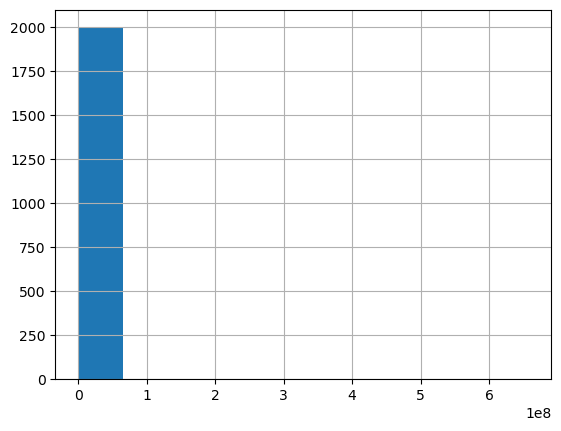

In [14]:
df["Sales"].hist()

plt.show()

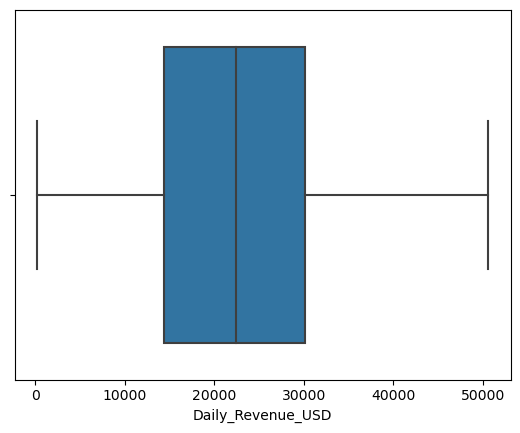

In [15]:
sns.boxplot(x=df["Daily_Revenue_USD"])

plt.show()

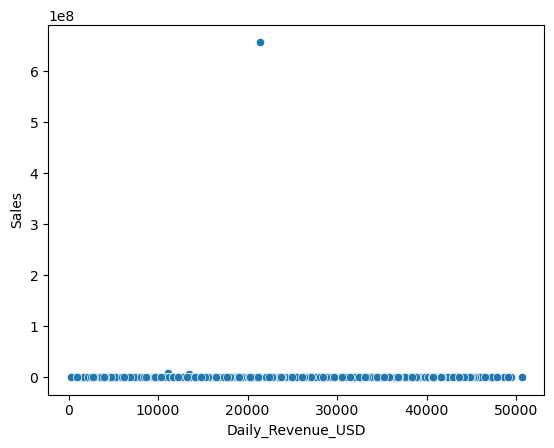

In [16]:
sns.scatterplot(
    x="Daily_Revenue_USD",
    y="Sales",
    data=df
)

plt.show()

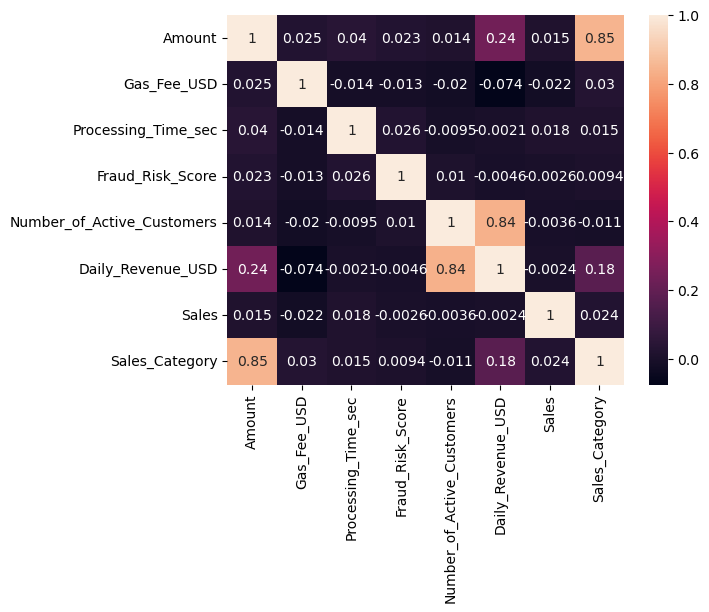

In [17]:
correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True)

plt.show()

df["Sales_Category".value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.show()

### APPLYING MODEL 

In [28]:
X = df[["Amount", "Gas_Fee_USD", "Daily_Revenue_USD"]]

y = df["Sales_Category"] 

In [33]:
X = df[["Amount", "Gas_Fee_USD", "Daily_Revenue_USD"]]

y = df["Sales_Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [34]:
model = GaussianNB()

In [35]:
model.fit(X_train, y_train)

GaussianNB()

In [36]:
predictions = model.predict(X_test)

In [37]:
accuracy_score(y_test, predictions)

0.975

In [38]:
cm = confusion_matrix(y_test, predictions)

pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

,Predicted 0,Predicted 1
Actual 0,196,6
Actual 1,4,194


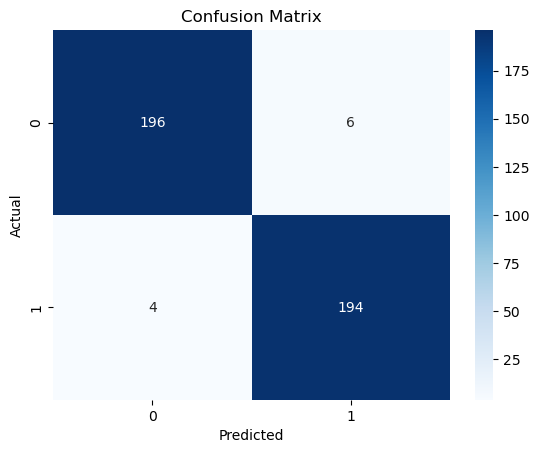

In [39]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [40]:
report = classification_report(
    y_test,
    predictions,
    output_dict=True
)

pd.DataFrame(report).transpose()

,precision,recall,f1-score,support
0,0.98000,0.970297,0.975124,202.000
1,0.97000,0.979798,0.974874,198.000
accuracy,0.97500,0.975000,0.975000,0.975
macro avg,0.97500,0.975048,0.974999,400.000
weighted avg,0.97505,0.975000,0.975001,400.000


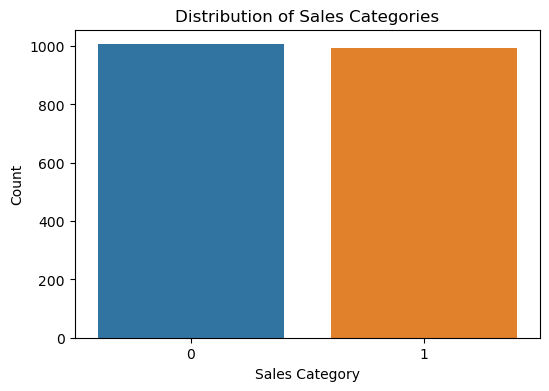

In [41]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Sales_Category"]
)

plt.title("Distribution of Sales Categories")
plt.xlabel("Sales Category")
plt.ylabel("Count")

plt.show()